# Single-Asset Timing with Trend Pullbacks and vectorbt

This notebook builds a single-asset timing signal: trade long when the trend is positive and the residual is temporarily cheap. It runs through a transparent pandas backtest first and then shows how to route the same signal to vectorbt.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
for path in [ROOT / "src", ROOT / "examples"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

In [2]:
prices = fetch_yahoo_prices(["SPY", "QQQ"], start="2016-01-01", cache_dir=ROOT / "examples" / "quant_trading" / "data" / "cache")
features = walkforward_decompose(prices, method="STL", period=63, train_window=252, step=21)
entries, exits = trend_pullback_signals(prices, features, residual_entry_z=-1.0, residual_exit_z=0.25)
result = backtest_long_short_signals(prices, entries, exits, fee_bps=1.0, slippage_bps=2.0)
result.stats_frame()

,value
total_return,0.579944
cagr,0.045116
volatility,0.130780
sharpe,0.402986
max_drawdown,-0.308406
calmar,0.146288
hit_rate,0.173047
average_turnover,0.019142
average_gross_exposure,0.305513
fee_bps,1.000000


## Visualization: SPY signal overlay

Entries and exits are drawn on recent SPY prices to make the trend-pullback timing rule inspectable.

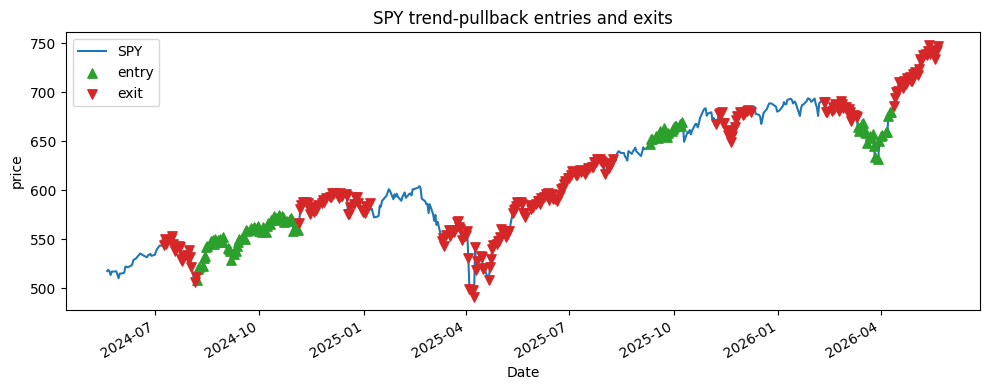

In [3]:
asset = "SPY"
window = prices.index[-504:]
price_line = prices.loc[window, asset]
entry_points = entries.loc[window, asset].fillna(False).astype(bool)
exit_points = exits.loc[window, asset].fillna(False).astype(bool)
fig, ax = plt.subplots(figsize=(10, 4))
price_line.plot(ax=ax, color="tab:blue", linewidth=1.5, title="SPY trend-pullback entries and exits")
ax.scatter(entry_points[entry_points].index, price_line.loc[entry_points[entry_points].index], marker="^", color="tab:green", s=45, label="entry", zorder=3)
ax.scatter(exit_points[exit_points].index, price_line.loc[exit_points[exit_points].index], marker="v", color="tab:red", s=45, label="exit", zorder=3)
ax.set_ylabel("price")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


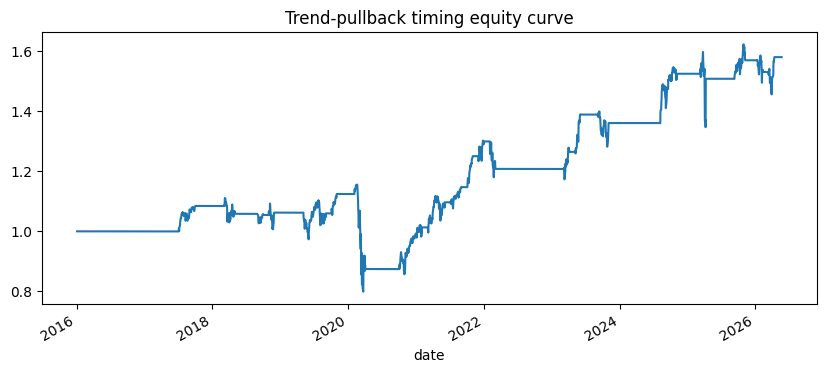

In [4]:
ax = result.equity.plot(figsize=(10, 4), title="Trend-pullback timing equity curve")
ax.set_xlabel("date")
plt.show()

## Visualization: drawdown and trading intensity

The equity curve is paired with underwater drawdown and turnover to reveal risk and implementation pressure.

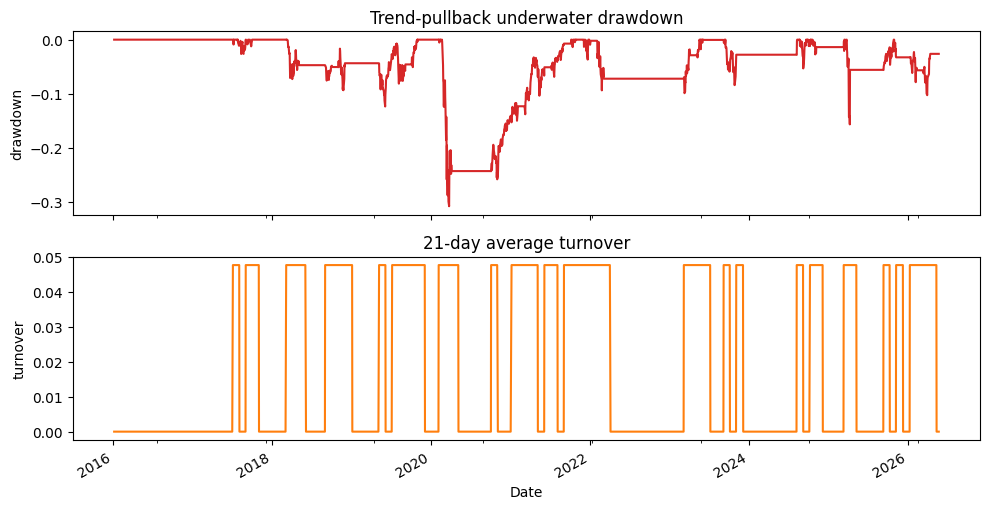

In [5]:
drawdown = result.equity / result.equity.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
drawdown.plot(ax=axes[0], color="tab:red", title="Trend-pullback underwater drawdown")
result.turnover.rolling(21, min_periods=1).mean().plot(ax=axes[1], color="tab:orange", title="21-day average turnover")
axes[0].set_ylabel("drawdown")
axes[1].set_ylabel("turnover")
plt.tight_layout()
plt.show()


## Optional: vectorbt adapter

Install vectorbt first if needed. The same entry/exit matrices can be passed to `Portfolio.from_signals` through the adapter.

In [6]:
from quant_trading.frameworks import run_vectorbt_from_signals

# portfolio = run_vectorbt_from_signals(prices, entries, exits, fees=0.0001, slippage=0.0002)
# portfolio.stats()